# Multi-Method Descriptor Importance Analysis

This notebook evaluates the relative importance of the eight physicochemical descriptors for predicting cytotoxicity, using a combined score that aggregates six weighted components: Pearson correlation, Spearman correlation, mutual information, Random Forest importance, permutation importance, and the inverse Variance Inflation Factor. The final sections apply two additional robustness checks: a fully decorrelated (residualized) importance analysis, and a conditional analysis of the two most correlated descriptors.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
RANDOM_SEED = 0


## 1. Data loading

In [2]:
data = pd.read_csv("NanoTox__unidas.csv")
target = 'class'
exclude = ['NPs', target]
predictors = [c for c in data.columns if c not in exclude]

for c in predictors:
    data[c] = pd.to_numeric(data[c], errors='coerce')

data = data.dropna(subset=[target])
data[target] = data[target].astype(int)

X = data[predictors].fillna(data[predictors].median())
y = data[target].values

print(f"Rows: {len(data)}  Predictors: {predictors}")


Rows: 1363  Predictors: ['hydrosize', 'surfcharge', 'surfarea', 'Ec', 'Expotime', 'dosage', 'e', 'NOxygen']


## 2. Individual importance metrics

Six components are computed for each descriptor: Pearson correlation, Spearman correlation, mutual information, Random Forest importance, permutation importance, and the inverse Variance Inflation Factor. Each component is min-max normalized to the [0, 1] range before combination.

In [3]:
pearson = {c: abs(pearsonr(X[c].values, y)[0]) for c in predictors}
pearson_p = {c: pearsonr(X[c].values, y)[1] for c in predictors}
spearman = {c: abs(spearmanr(X[c].values, y).correlation) for c in predictors}
spearman_p = {c: spearmanr(X[c].values, y).pvalue for c in predictors}
mi = dict(zip(predictors, mutual_info_classif(X, y, random_state=RANDOM_SEED)))

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, class_weight='balanced').fit(X, y)
rf_imp = dict(zip(predictors, rf.feature_importances_))

perm = permutation_importance(rf, X, y, n_repeats=30, random_state=RANDOM_SEED, n_jobs=1)
perm_imp = dict(zip(predictors, perm.importances_mean))

vif = {}
for i, c in enumerate(predictors):
    vif[c] = variance_inflation_factor(X.values, i)

def normalise_dict(d):
    vals = np.array([d[k] for k in predictors])
    rng = vals.max() - vals.min()
    if rng == 0:
        return dict(zip(predictors, np.zeros(len(predictors))))
    return dict(zip(predictors, (vals - vals.min()) / rng))

n_pearson = normalise_dict(pearson)
n_spearman = normalise_dict(spearman)
n_mi = normalise_dict(mi)
n_rf = normalise_dict(rf_imp)
n_perm = normalise_dict(perm_imp)
inv_vif = {c: 1.0 / vif[c] for c in predictors}
n_inv_vif = normalise_dict(inv_vif)


## 3. Combined weighted score

Model-based methods (Random Forest and permutation importance) receive the highest weight (1.5 each), as direct measures of predictive relevance. Mutual information receives an intermediate weight (1.2) for its sensitivity to non-linear dependencies. The two correlation measures receive a baseline weight (1.0 each). The inverse-VIF term receives the lowest weight (0.8), since it reflects redundancy rather than predictive power.

In [4]:
weights = {'pearson': 1.0, 'spearman': 1.0, 'mi': 1.2, 'rf': 1.5, 'perm': 1.5, 'inv_vif': 0.8}
weight_sum = sum(weights.values())

combined = {}
for c in predictors:
    parts = np.array([n_pearson[c], n_spearman[c], n_mi[c], n_rf[c], n_perm[c], n_inv_vif[c]])
    w = np.array([weights['pearson'], weights['spearman'], weights['mi'], weights['rf'], weights['perm'], weights['inv_vif']])
    combined[c] = float(np.dot(parts, w) / weight_sum)

out = pd.DataFrame({
    'pearson_corr': pd.Series(pearson), 'pearson_p': pd.Series(pearson_p),
    'spearman_corr': pd.Series(spearman), 'spearman_p': pd.Series(spearman_p),
    'mi': pd.Series(mi), 'rf_imp': pd.Series(rf_imp), 'perm_imp': pd.Series(perm_imp),
    'vif': pd.Series(vif), 'combined': pd.Series(combined)
}).sort_values('combined', ascending=False)

out.to_csv('feature_importance_summary.csv')
print('Wrote', 'feature_importance_summary.csv')
out


Wrote feature_importance_summary.csv


,pearson_corr,pearson_p,spearman_corr,spearman_p,mi,rf_imp,perm_imp,vif,combined
dosage,0.176943,4.752282e-11,0.384852,2.362825e-49,0.284000,0.400759,0.267254,1.101951,0.827671
NOxygen,0.538880,1.663235e-103,0.569070,8.464748e-118,0.215017,0.137473,0.011959,1.525841,0.517312
surfarea,0.337319,1.274037e-37,0.419670,2.850035e-59,0.246640,0.112050,0.019687,1.606410,0.416147
hydrosize,0.243075,8.814144e-20,0.164138,1.090261e-09,0.284692,0.084923,0.002959,1.075089,0.371792
e,0.359135,9.277871e-43,0.482919,1.485746e-80,0.214640,0.087927,0.000758,2.259985,0.347535
Expotime,0.258809,2.677779e-22,0.322450,2.387116e-34,0.066400,0.087422,0.105111,1.090556,0.341169
surfcharge,0.217711,4.366739e-16,0.229706,8.866568e-18,0.274653,0.044395,0.027733,1.593268,0.304582
Ec,0.029375,2.784837e-01,0.328000,1.504971e-35,0.217378,0.045051,0.000734,1.518071,0.227447


## 4. Combined importance ranking

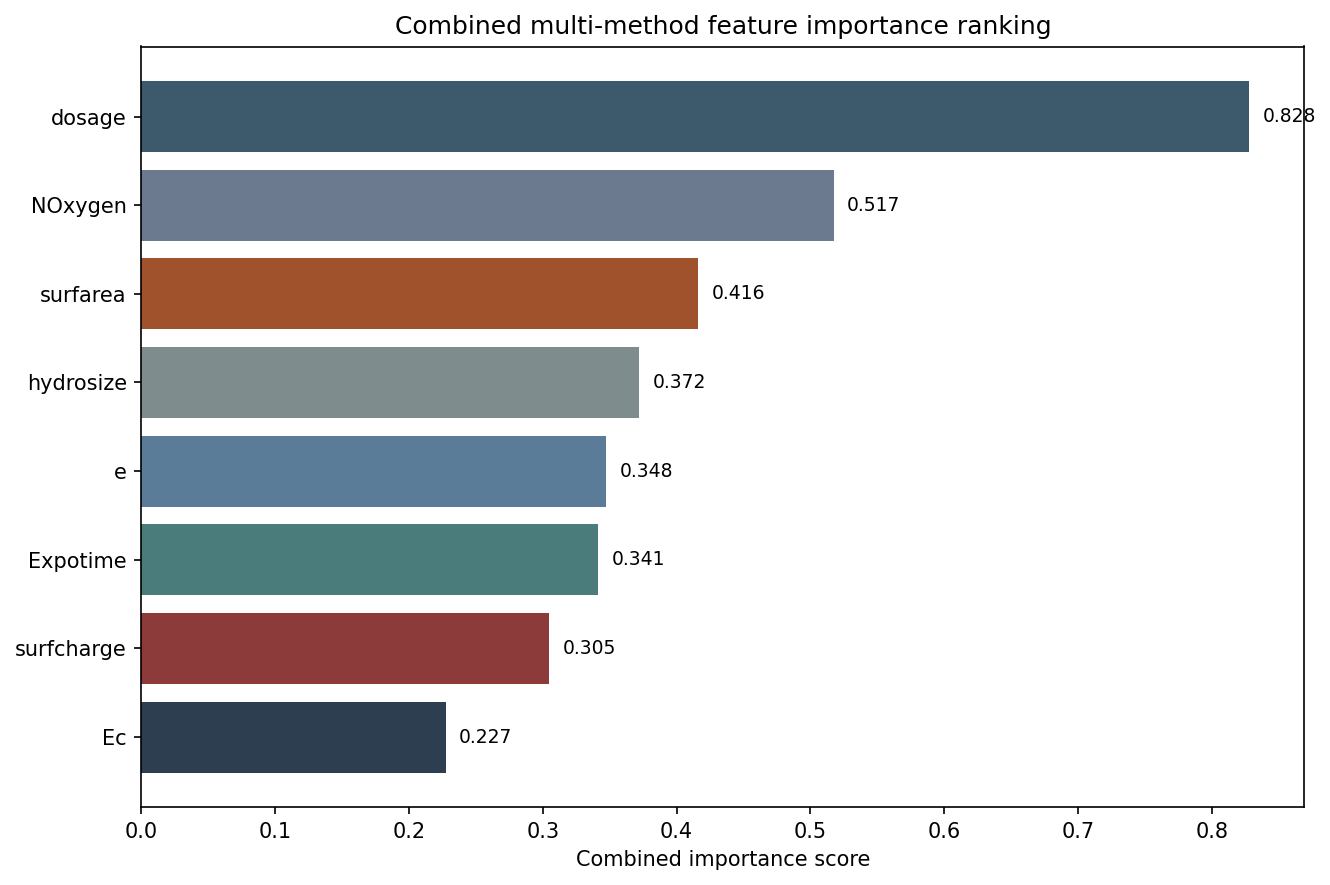

In [5]:
colors = ["#2c3e50", "#8c3a3a", "#4a7c7c", "#5b7c99", "#7f8c8d", "#a0522d", "#6b7a8f", "#3d5a6c"][:len(predictors)] if len(predictors) <= 8 else sns.color_palette("Greys", len(predictors))
plot_order = out.sort_values('combined')
plt.figure(figsize=(9, 6))
plt.barh(plot_order.index, plot_order['combined'], color=colors)
plt.xlabel('Combined importance score')
plt.title('Combined multi-method feature importance ranking')
for i, (idx, row) in enumerate(plot_order.iterrows()):
    plt.text(row['combined'] + 0.01, i, f"{row['combined']:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_combined_importance_ranking.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Decorrelated importance analysis

Each descriptor is regressed on the remaining seven and replaced by its residual, the fraction of its variance that is not linearly explained by any of the other descriptors. Random Forest importance and permutation importance are then recomputed on this fully decorrelated representation, removing all shared linear information rather than merely bounding it.

In [6]:
from sklearn.linear_model import LinearRegression

X_resid = X.copy()
for f in predictors:
    others = [c for c in predictors if c != f]
    reg = LinearRegression().fit(X[others], X[f])
    X_resid[f] = X[f] - reg.predict(X[others])

rf_decorr = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, class_weight='balanced').fit(X_resid, y)
decorr_rf_imp = dict(zip(predictors, rf_decorr.feature_importances_))

perm_decorr = permutation_importance(rf_decorr, X_resid, y, n_repeats=50, random_state=RANDOM_SEED, n_jobs=1)
decorr_perm_imp = dict(zip(predictors, perm_decorr.importances_mean))

decorr_table = pd.DataFrame({
    'Variable': predictors,
    'RF importance (original)': [rf_imp[f] for f in predictors],
    'RF importance (decorrelated)': [decorr_rf_imp[f] for f in predictors],
    'Permutation importance (decorrelated)': [decorr_perm_imp[f] for f in predictors],
}).sort_values('RF importance (decorrelated)', ascending=False)

decorr_table.to_csv('decorrelated_importance_analysis.csv', index=False)
decorr_table.round(3)


,Variable,RF importance (original),RF importance (decorrelated),Permutation importance (decorrelated)
5,dosage,0.401,0.257,0.195
7,NOxygen,0.137,0.165,0.109
2,surfarea,0.112,0.128,0.037
0,hydrosize,0.085,0.118,0.034
4,Expotime,0.087,0.112,0.052
6,e,0.088,0.100,0.008
1,surfcharge,0.044,0.061,0.009
3,Ec,0.045,0.059,0.000


## 6. Conditional analysis: dose-response descriptor pair

Dosage and the number of oxygen atoms are the two highest-ranked descriptors and are moderately correlated with surface area. This section evaluates whether the number-of-oxygen-atoms descriptor retains its predictive signal once its correlation with surface area is accounted for: by removing surface area from the feature set, by removing the number-of-oxygen-atoms descriptor and checking whether surface area absorbs the signal, and by computing the partial correlation between the number-of-oxygen-atoms descriptor and the outcome, controlling for surface area.

In [7]:
r_raw, p_raw = pearsonr(X['NOxygen'], X['surfarea'])
print(f"Correlation, NOxygen vs surfarea (combined dataset): r={r_raw:.3f}, p={p_raw:.2e}")

X_no_surfarea = X.drop(columns=['surfarea'])
rf_a = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, class_weight='balanced').fit(X_no_surfarea, y)
perm_a = permutation_importance(rf_a, X_no_surfarea, y, n_repeats=50, random_state=RANDOM_SEED, n_jobs=1)
print(f"\nWithout surfarea, NOxygen importance: RF={dict(zip(X_no_surfarea.columns, rf_a.feature_importances_))['NOxygen']:.3f}  "
      f"Permutation={dict(zip(X_no_surfarea.columns, perm_a.importances_mean))['NOxygen']:.3f}  "
      f"(reference with all eight descriptors: RF={rf_imp['NOxygen']:.3f}, Permutation={perm_imp['NOxygen']:.3f})")

X_no_NOxygen = X.drop(columns=['NOxygen'])
rf_b = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, class_weight='balanced').fit(X_no_NOxygen, y)
print(f"Without NOxygen, surfarea importance: RF={dict(zip(X_no_NOxygen.columns, rf_b.feature_importances_))['surfarea']:.3f}  "
      f"(reference with all eight descriptors: RF={rf_imp['surfarea']:.3f})")

def partial_corr(x, yv, z):
    rx = x - LinearRegression().fit(z.reshape(-1,1), x).predict(z.reshape(-1,1))
    ry = yv - LinearRegression().fit(z.reshape(-1,1), yv.astype(float)).predict(z.reshape(-1,1))
    return pearsonr(rx, ry)

r_simple, p_simple = pearsonr(X['NOxygen'].values, y)
r_partial, p_partial = partial_corr(X['NOxygen'].values, y, X['surfarea'].values)
print(f"\nNOxygen-outcome correlation, unconditional: r={r_simple:.3f} (p={p_simple:.1e})")
print(f"NOxygen-outcome correlation, controlling for surfarea: r={r_partial:.3f} (p={p_partial:.1e})")
print(f"Fraction of the unconditional signal retained: {100*abs(r_partial)/abs(r_simple):.0f}%")


Correlation, NOxygen vs surfarea (combined dataset): r=0.510, p=3.15e-91



Without surfarea, NOxygen importance: RF=0.168  Permutation=0.031  (reference with all eight descriptors: RF=0.137, Permutation=0.012)


Without NOxygen, surfarea importance: RF=0.133  (reference with all eight descriptors: RF=0.112)

NOxygen-outcome correlation, unconditional: r=-0.539 (p=1.7e-103)
NOxygen-outcome correlation, controlling for surfarea: r=-0.453 (p=6.3e-70)
Fraction of the unconditional signal retained: 84%
